## 1. Carga del conjunto de datos

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Cargar el dataset
df = pd.read_csv('archivos semana 2/Automobile.csv')

# Convertir horsepower a numérico (tiene valores faltantes representados como '')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Mapear origin a etiquetas legibles (ya viene como texto)
origin_map = {'usa': 1, 'europe': 2, 'japan': 3}
df['origin_num'] = df['origin'].map(origin_map)

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print(f'Valores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df.head()

Filas: 398 | Columnas: 10
Valores nulos por columna:
horsepower    6
dtype: int64


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,origin_num
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa,1
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa,1
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa,1
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa,1
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa,1


In [8]:
# Resumen estadístico
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_num
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## 2. Gráfico de Dispersión: `mpg` vs `weight`

Permite visualizar la relación entre el peso del automóvil y su consumo de combustible. Se espera una correlación negativa: a mayor peso, menor eficiencia.

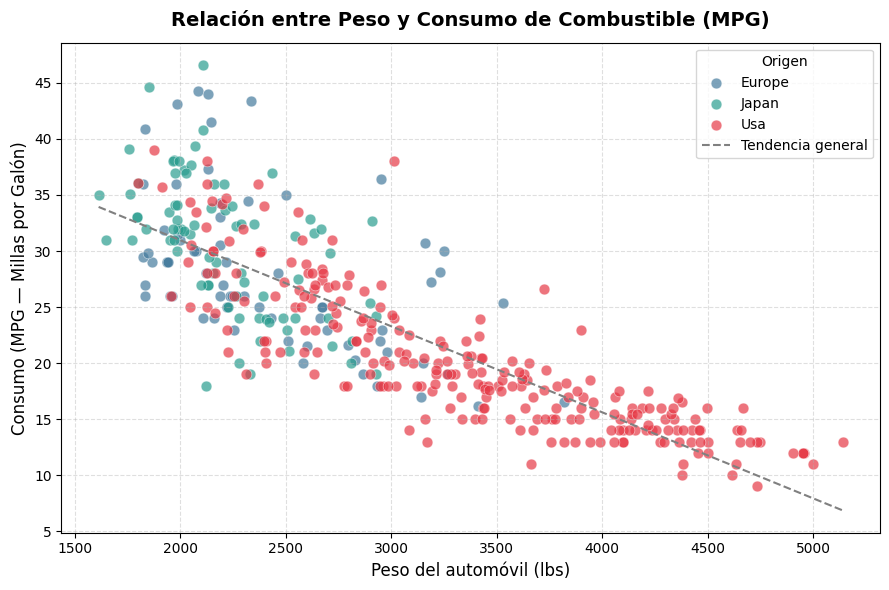

Correlación (weight, mpg): -0.8317


In [9]:
# Paleta de colores por origen
color_map = {'usa': '#e63946', 'europe': '#457b9d', 'japan': '#2a9d8f'}
colors = df['origin'].map(color_map)

fig, ax = plt.subplots(figsize=(9, 6))

for origen, grupo in df.groupby('origin'):
    ax.scatter(
        grupo['weight'], grupo['mpg'],
        c=color_map[origen], label=origen.capitalize(),
        alpha=0.7, edgecolors='white', linewidths=0.4, s=60
    )

# Línea de tendencia general
mask = df[['weight', 'mpg']].notna().all(axis=1)
z = np.polyfit(df.loc[mask, 'weight'], df.loc[mask, 'mpg'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['weight'].min(), df['weight'].max(), 200)
ax.plot(x_line, p(x_line), '--', color='gray', linewidth=1.5, label='Tendencia general')

ax.set_title('Relación entre Peso y Consumo de Combustible (MPG)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Peso del automóvil (lbs)', fontsize=12)
ax.set_ylabel('Consumo (MPG — Millas por Galón)', fontsize=12)
ax.legend(title='Origen', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('scatter_mpg_weight.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlación (weight, mpg):', round(df['weight'].corr(df['mpg']), 4))

## 3. Histograma: Distribución del Consumo de Combustible (`mpg`)

El histograma permite analizar la forma de la distribución: simetría, sesgo, modas y rango de valores típicos.

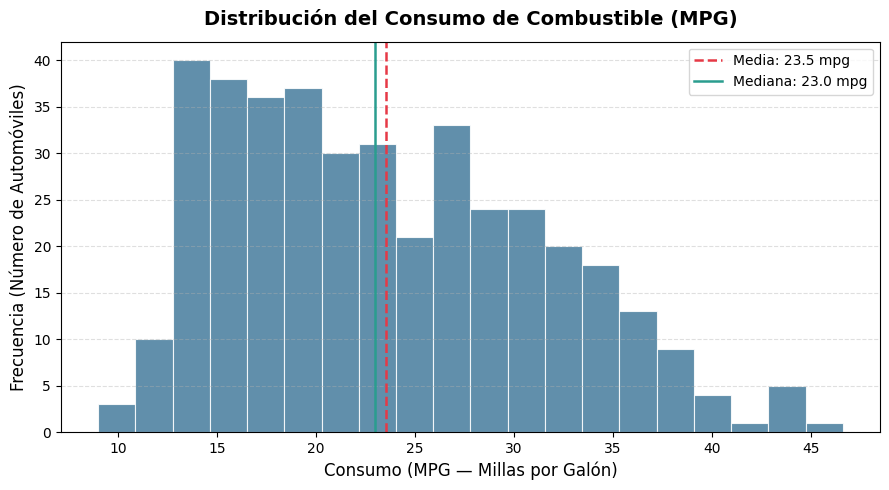

Media: 23.51 | Mediana: 23.00 | Desv. estándar: 7.82
Min: 9.0 | Max: 46.6


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

n, bins, patches = ax.hist(
    df['mpg'].dropna(), bins=20,
    color='#457b9d', edgecolor='white', linewidth=0.8, alpha=0.85
)

# Líneas de media y mediana
media  = df['mpg'].mean()
mediana = df['mpg'].median()
ax.axvline(media,   color='#e63946', linestyle='--', linewidth=1.8, label=f'Media: {media:.1f} mpg')
ax.axvline(mediana, color='#2a9d8f', linestyle='-',  linewidth=1.8, label=f'Mediana: {mediana:.1f} mpg')

ax.set_title('Distribución del Consumo de Combustible (MPG)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Consumo (MPG — Millas por Galón)', fontsize=12)
ax.set_ylabel('Frecuencia (Número de Automóviles)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('histograma_mpg.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Media: {media:.2f} | Mediana: {mediana:.2f} | Desv. estándar: {df["mpg"].std():.2f}')
print(f'Min: {df["mpg"].min()} | Max: {df["mpg"].max()}')

## 4. Diagrama de Caja (Boxplot): `cylinders` y `origin`

Los boxplots muestran la distribución del consumo de combustible (`mpg`) agrupada por cada variable categórica, permitiendo identificar valores atípicos (outliers) y diferencias entre grupos.

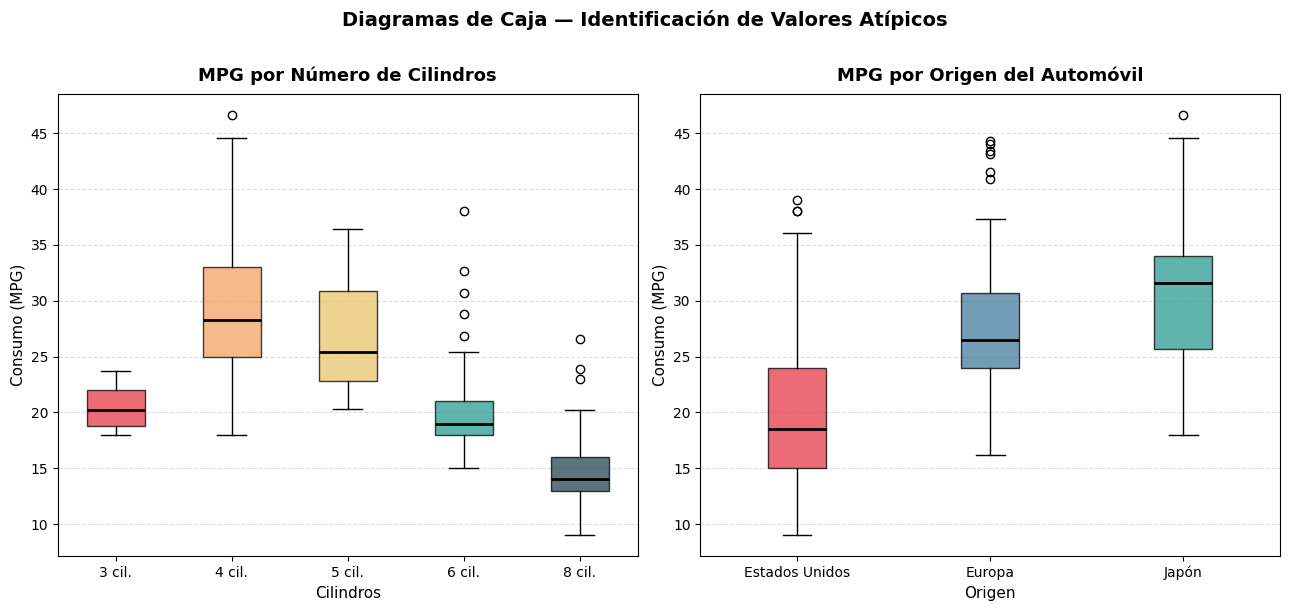

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Boxplot por Cylinders ──
cilindros_unicos = sorted(df['cylinders'].dropna().unique())
datos_cil = [df.loc[df['cylinders'] == c, 'mpg'].dropna().values for c in cilindros_unicos]
colores_cil = ['#e63946', '#f4a261', '#e9c46a', '#2a9d8f', '#264653']

bp1 = axes[0].boxplot(
    datos_cil, patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp1['boxes'], colores_cil):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[0].set_xticklabels([f'{int(c)} cil.' for c in cilindros_unicos], fontsize=10)
axes[0].set_title('MPG por Número de Cilindros', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Cilindros', fontsize=11)
axes[0].set_ylabel('Consumo (MPG)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# ── Boxplot por Origin ──
origenes = ['usa', 'europe', 'japan']
etiquetas_origen = ['Estados Unidos', 'Europa', 'Japón']
datos_orig = [df.loc[df['origin'] == o, 'mpg'].dropna().values for o in origenes]
colores_orig = ['#e63946', '#457b9d', '#2a9d8f']

bp2 = axes[1].boxplot(
    datos_orig, patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp2['boxes'], colores_orig):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[1].set_xticklabels(etiquetas_origen, fontsize=10)
axes[1].set_title('MPG por Origen del Automóvil', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Origen', fontsize=11)
axes[1].set_ylabel('Consumo (MPG)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Diagramas de Caja — Identificación de Valores Atípicos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_cylinders_origin.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Gráfico de Barras: Distribución por `model_year` y `origin`

Muestra cuántos automóviles hay por año de modelo, diferenciando el origen con colores para analizar tendencias históricas de producción.

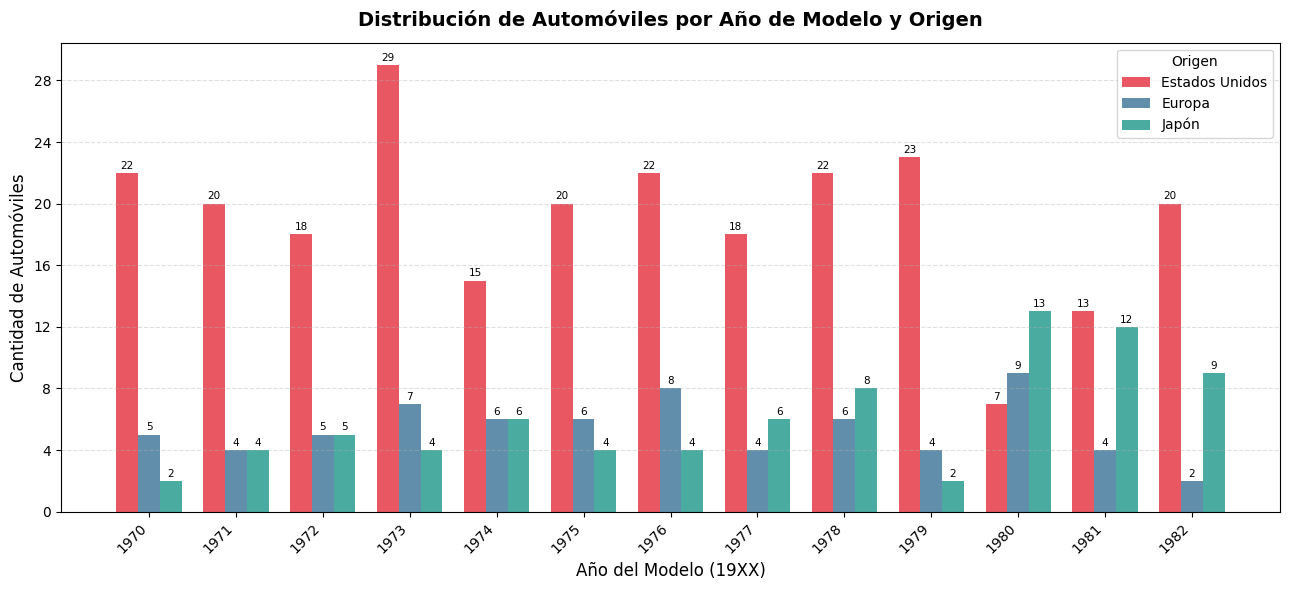

Total por origen:
origin
Estados Unidos    249
Japón              79
Europa             70
Name: count, dtype: int64


In [12]:
# Tabla pivote: filas=model_year, columnas=origin, valores=conteo
pivot = df.groupby(['model_year', 'origin']).size().unstack(fill_value=0)

# Asegurar orden de columnas
for col in ['usa', 'europe', 'japan']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['usa', 'europe', 'japan']]

anios = pivot.index.astype(str)
x = np.arange(len(anios))
ancho = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

barras_usa    = ax.bar(x - ancho, pivot['usa'],    ancho, label='Estados Unidos', color='#e63946', alpha=0.85)
barras_europe = ax.bar(x,         pivot['europe'], ancho, label='Europa',         color='#457b9d', alpha=0.85)
barras_japan  = ax.bar(x + ancho, pivot['japan'],  ancho, label='Japón',          color='#2a9d8f', alpha=0.85)

# Etiquetas de valor sobre cada barra
def etiquetar(barras):
    for barra in barras:
        h = barra.get_height()
        if h > 0:
            ax.text(
                barra.get_x() + barra.get_width() / 2, h + 0.15,
                str(int(h)), ha='center', va='bottom', fontsize=7.5
            )

etiquetar(barras_usa)
etiquetar(barras_europe)
etiquetar(barras_japan)

ax.set_title('Distribución de Automóviles por Año de Modelo y Origen', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Año del Modelo (19XX)', fontsize=12)
ax.set_ylabel('Cantidad de Automóviles', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(['19' + a for a in anios], rotation=45, ha='right', fontsize=10)
ax.legend(title='Origen', fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('barras_model_year_origin.png', dpi=150, bbox_inches='tight')
plt.show()

print('Total por origen:')
print(df['origin'].value_counts().rename({'usa': 'Estados Unidos', 'europe': 'Europa', 'japan': 'Japón'}))